# Recommender system on **movielens** dataset

## Load data

In [5]:
!pip install "numpy<2.0.0"

In [6]:
!pip install scikit-surprise

In [7]:
from surprise import Dataset

In [8]:
data = Dataset.load_builtin("ml-100k", prompt=False) # ml-1m

## Visualization

In [9]:
import pandas as pd

In [10]:
df = pd.DataFrame(data.raw_ratings, columns=["userId", "movieId", "rating", "timestamp"])
df

,userId,movieId,rating,timestamp
0,196,242,3.0,881250949
1,186,302,3.0,891717742
2,22,377,1.0,878887116
3,244,51,2.0,880606923
4,166,346,1.0,886397596
...,...,...,...,...
99995,880,476,3.0,880175444
99996,716,204,5.0,879795543
99997,276,1090,1.0,874795795
99998,13,225,2.0,882399156


In [11]:
df.apply("nunique")

,0
userId,943
movieId,1682
rating,5
timestamp,49282


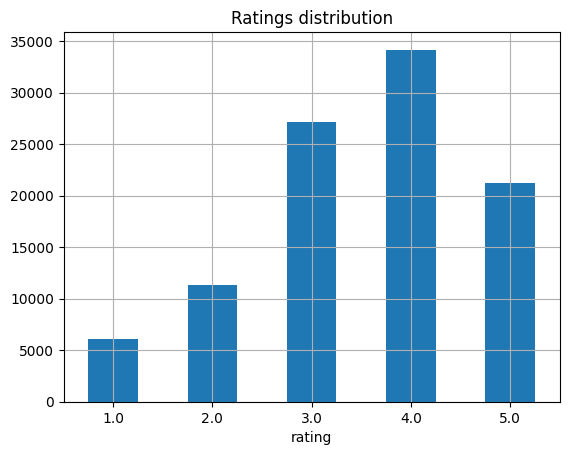

In [12]:
df["rating"].value_counts().sort_index().plot.bar(title="Ratings distribution", rot=0).grid();

## Train and test split

In [13]:
from surprise.model_selection import train_test_split

In [14]:
trainset, testset = train_test_split(data, test_size=0.25)

# EDA


In [15]:
import matplotlib.pyplot as plt

In [16]:
df_train = pd.DataFrame(
    data=[i for i in trainset.all_ratings()],
    columns=["user", "movie", "rating"],
)

df_train.shape

(75000, 3)

In [17]:
users_train = df_train.groupby("user")["rating"].count()

print("Mean:   ", users_train.mean())
print("Std:    ", users_train.std())
print("Median: ", users_train.median())

Mean:    79.53340402969248
Std:     75.89209499389007
Median:  48.0


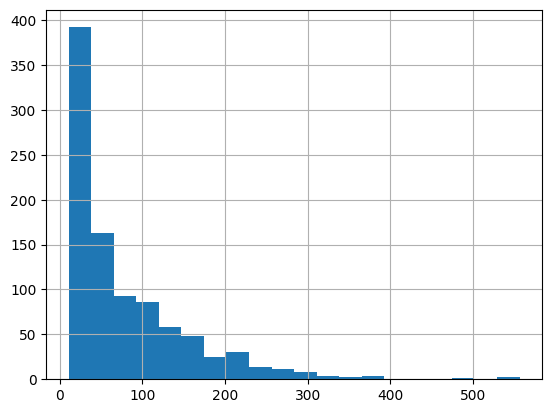

In [22]:
users_train.hist(bins=100);

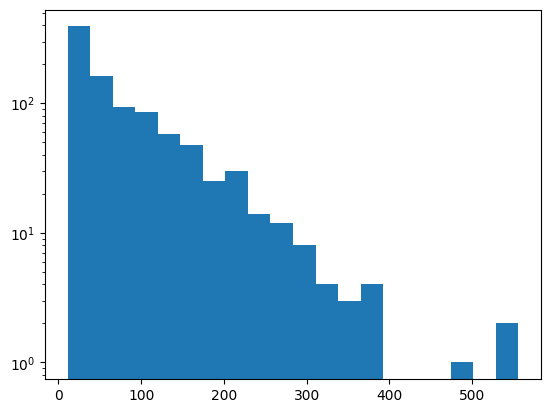

In [23]:
plt.hist(users_train, bins=100, log=True);

In [24]:
movies_train = df_train.groupby("movie")["rating"].count()

print("Mean:   ", movies_train.mean())
print("Std:    ", movies_train.std())
print("Median: ", movies_train.median())

Mean:    45.703839122486286
Std:     60.73343428565673
Median:  21.0


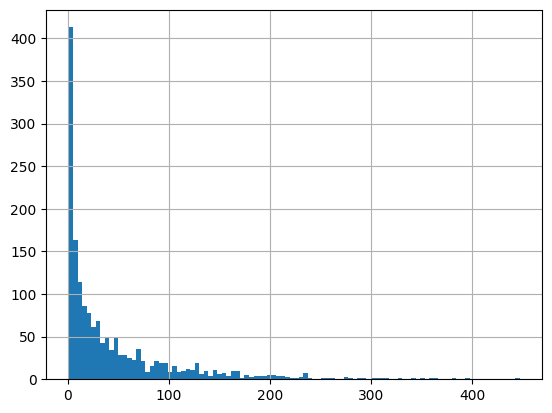

In [25]:
movies_train.hist(bins=100);

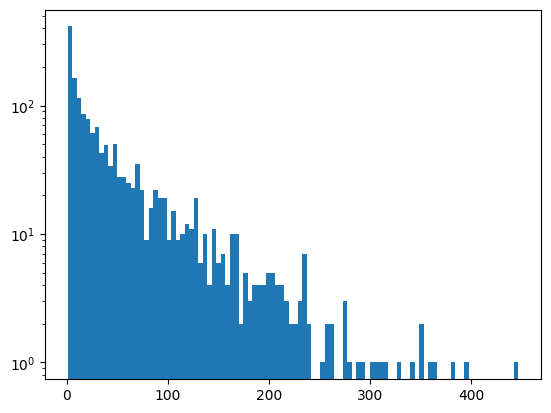

In [26]:
plt.hist(movies_train, bins=100, log=True);

## [Last.fm](https://en.wikipedia.org/wiki/Last.fm) dataset



In [27]:
!pip install implicit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.3/70.3 kB 3.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
ERROR: Operation cancelled by user


In [ ]:
from implicit.datasets import _download

/usr/local/lib/python3.12/dist-packages/implicit/gpu/__init__.py:13: UserWarning: CUDA extension is built, but disabling GPU support because of 'Cuda Error: CUDA driver version is insufficient for CUDA runtime version (/tmp/pip-install-isbwecl0/implicit_068af72385554fc9bdd2a060812eea2e/./implicit/gpu/utils.h:71)'
  warnings.warn(


In [ ]:
import os
import zipfile
import implicit.datasets

# Download the dataset
url = "http://files.grouplens.org/datasets/hetrec2011/hetrec2011-lastfm-2k.zip"
dataset_path = "lastfm.zip"
_download.download_file(url, dataset_path)

with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall("lastfm_data")

# users_artists = pd.read_csv('lastfm_data/user_artists.dat', sep='\t')
# artists = pd.read_csv('lastfm_data/artists.dat', sep='\t')
user_taggedartists = pd.read_csv('lastfm_data/user_taggedartists.dat', sep='\t')

0.00B [00:00, ?B/s]

NameError: name 'pd' is not defined

In [ ]:
user_taggedartists.shape

(186479, 6)

In [ ]:
user_taggedartists.head()

,userID,artistID,tagID,day,month,year
0,2,52,13,1,4,2009
1,2,52,15,1,4,2009
2,2,52,18,1,4,2009
3,2,52,21,1,4,2009
4,2,52,41,1,4,2009


In [ ]:
lastfm_users_tags = user_taggedartists.groupby("userID")["tagID"].count()

print("Mean:   ", lastfm_users_tags.mean())
print("Std:    ", lastfm_users_tags.std())
print("Median: ", lastfm_users_tags.median())

Mean:    98.56183932346723
Std:     224.5906456172717
Median:  20.0


In [ ]:
# lastfm_users_artists = user_taggedartists.groupby("userID")["artistID"].count()

# print("Mean:   ", lastfm_users_artists.mean())
# print("Std:    ", lastfm_users_artists.std())
# print("Median: ", lastfm_users_artists.median())

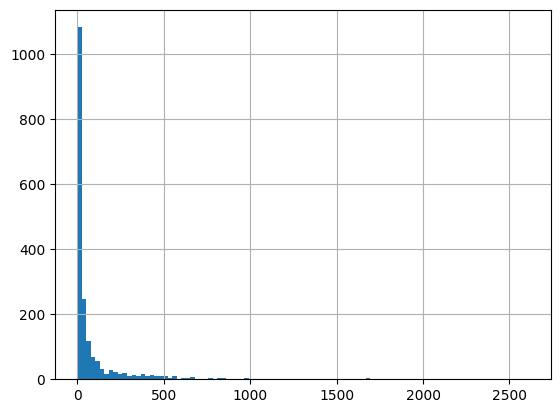

In [ ]:
user_taggedartists.groupby("userID")["artistID"].count().hist(bins=100);

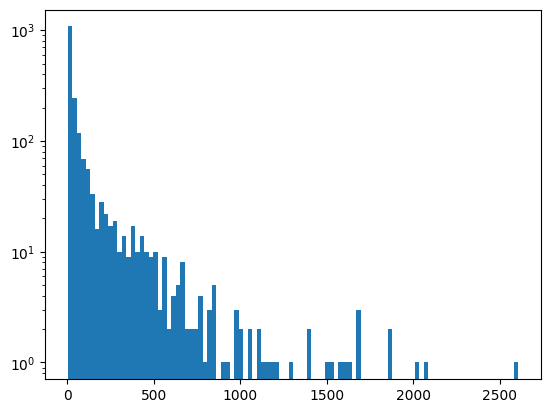

In [ ]:
plt.hist(user_taggedartists.groupby("userID")["artistID"].count(), bins=100, log=True);

## Simple model


In [28]:
from surprise import SVD, KNNBasic, accuracy

Binary classification task: 0 / 1

Accuracy = (num of correctly predicted examples) / (num(examples))

R - matrix of ratings

R ~ U Σ I, where U - matrix of user embeddings, I - matrix of item embeddings

In [29]:
algo = SVD()

In [30]:
algo.fit(trainset)

In [31]:
predictions = algo.test(testset)
accuracy.rmse(predictions);

RMSE: 0.9338


## Cross validation

In [32]:
from surprise.model_selection import cross_validate

In [33]:
algo = SVD()
cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=True)

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9310  0.9378  0.9394  0.9356  0.9352  0.9358  0.0028  
MAE (testset)     0.7325  0.7388  0.7410  0.7392  0.7380  0.7379  0.0029  
Fit time          1.79    4.31    1.36    1.38    1.41    2.05    1.14    
Test time         0.35    0.11    0.29    0.11    0.29    0.23    0.10    


{'test_rmse': array([0.93102206, 0.93775555, 0.93943347, 0.93561806, 0.93515705]),
 'test_mae': array([0.73249681, 0.7388327 , 0.7410406 , 0.73917646, 0.73797607]),
 'fit_time': (1.7942912578582764,
  4.310812473297119,
  1.3556113243103027,
  1.3830201625823975,
  1.412085771560669),
 'test_time': (0.347430944442749,
  0.10687756538391113,
  0.289165735244751,
  0.11294221878051758,
  0.29006505012512207)}

dataset: 10k

1.   2.   3.   4.   5  
2k | 2k | 2k | 2k | 2k

1) get 1, 2, 3, 4 for training and 5 for validation
2) get 1, 2, 3, 5 for training and 4 for validation
3) ...

## Grid search

In [34]:
from surprise.model_selection import GridSearchCV

In [35]:
params = {"n_epochs": [10, 20, 30, 50], "lr_all": [0.001, 0.01, 0.05], "reg_all": [0.01, 0.05, 0.1]}
grid = GridSearchCV(
    SVD,
    param_grid=params,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1,
    return_train_measures=True
)
grid.fit(data)

In [36]:
grid.best_score, grid.best_params

({'rmse': 0.9200063658509631, 'mae': 0.7270486452311226},
 {'rmse': {'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.1},
  'mae': {'n_epochs': 50, 'lr_all': 0.01, 'reg_all': 0.1}})

In [37]:
params = {"k": [10, 20, 40], "min_k": [1, 2, 5]}
grid = GridSearchCV(
    KNNBasic,
    param_grid=params,
    measures=["rmse", "mae"],
    cv=3,
    n_jobs=-1,
    return_train_measures=True,
)
grid.fit(data)

In [ ]:
knn_model = grid.best_estimator

grid.best_score, grid.best_params

({'rmse': 0.9858663698481838, 'mae': 0.7783787891621049},
 {'rmse': {'k': 20, 'min_k': 2}, 'mae': {'k': 20, 'min_k': 2}})

In [38]:
def get_top_n(predictions, n=3):
    """Return the top-N recommendation for each user from a set of predictions.

    Args:
        predictions(list of Prediction objects): The list of predictions, as
            returned by the test method of an algorithm.
        n(int): The number of recommendation to output for each user. Default
            is 10.

    Returns:
    A dict where keys are user (raw) ids and values are lists of tuples:
        [(raw item id, rating estimation), ...] of size n.
    """

    # First map the predictions to each user.
    top_n = {}
    for uid, iid, true_r, est, _ in predictions:
        top_n[uid] = top_n.get(uid, []) + [(iid, est)]

    # Then sort the predictions for each user and retrieve the k highest ones.
    for uid, user_ratings in top_n.items():
        user_ratings.sort(key=lambda x: x[1], reverse=True)
        top_n[uid] = user_ratings[:n]

    return top_n

In [39]:
algo = SVD(lr_all=0.01, n_epochs=50, reg_all=0.1, random_state=0)
algo.fit(trainset)
preds = algo.test(testset)

In [40]:
top_n = get_top_n(preds, n=3)
len(top_n)

942

In [41]:
all_recommends = []
for user_ratings in top_n.values():
    movies = [iid for (iid, _) in user_ratings]
    all_recommends += movies

uniq_movies = set(all_recommends)
len(uniq_movies)

416

In [42]:
freq_rcmnd = pd.Series(all_recommends).value_counts()
freq_rcmnd.head(10)

,count
50,94
127,70
313,67
318,65
100,59
483,56
174,53
12,47
181,47
64,46


In [43]:
df[df["movieId"] == "50"]

,userId,movieId,rating,timestamp
499,290,50,5.0,880473582
857,79,50,4.0,891271545
1052,2,50,5.0,888552084
1090,8,50,5.0,879362124
1121,274,50,5.0,878944679
...,...,...,...,...
99567,749,50,5.0,878846978
99643,886,50,5.0,876031501
99853,739,50,4.0,886958895
99928,903,50,5.0,891031329


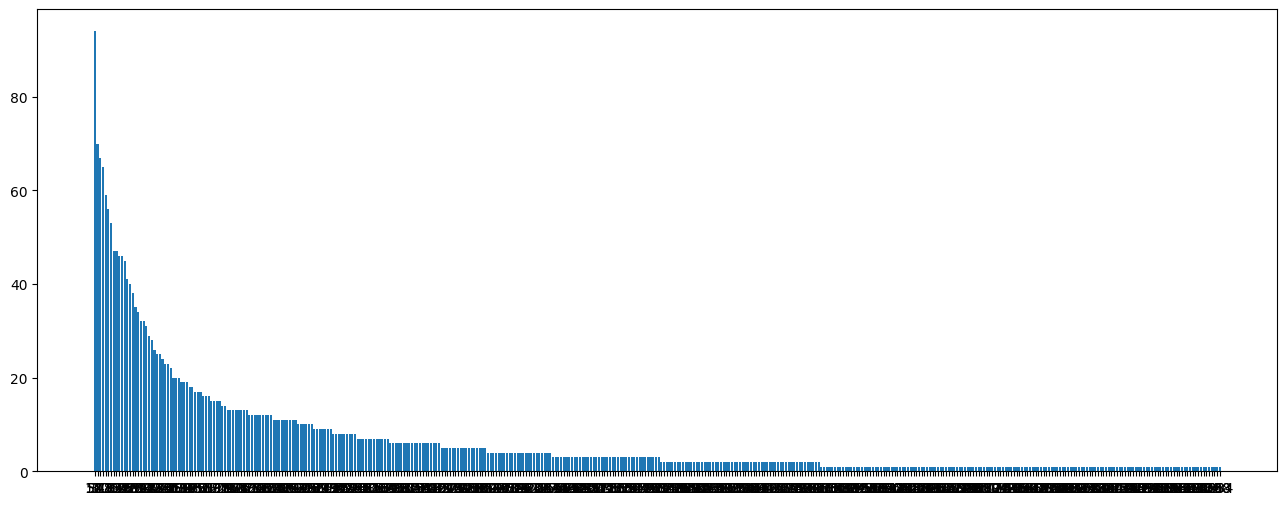

In [44]:
plt.figure(figsize=(16, 6))
plt.bar(freq_rcmnd.index, freq_rcmnd.values);

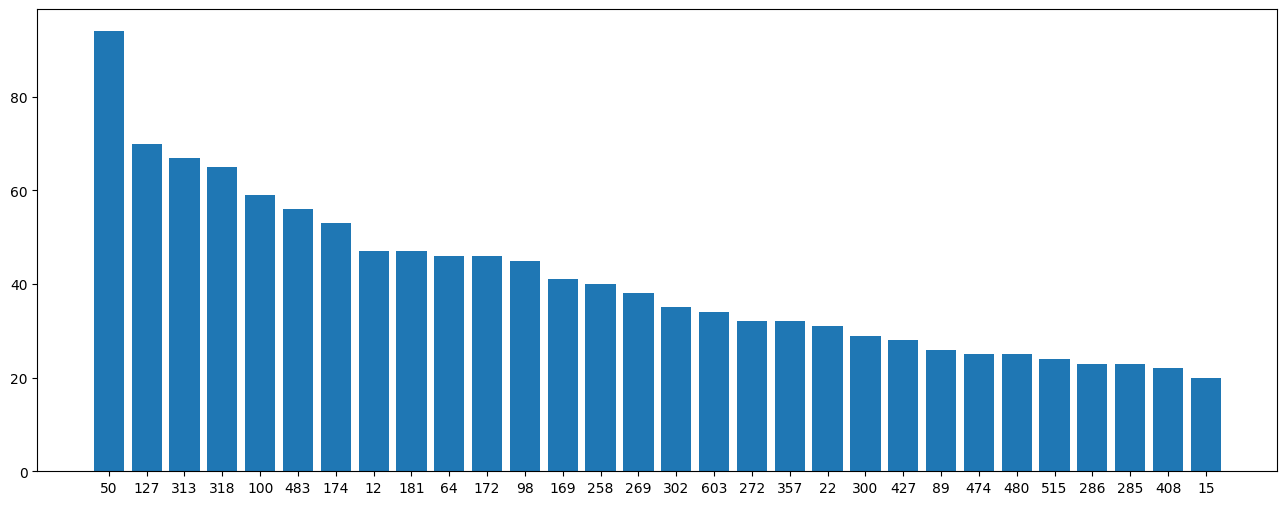

In [45]:
plt.figure(figsize=(16, 6))
plt.bar(freq_rcmnd.index[:30], freq_rcmnd.values[:30]);

# Correct validation

![Time series validation split](https://scikit-learn.org/stable/_images/sphx_glr_plot_cv_indices_013.png)


In [46]:
from sklearn.model_selection import TimeSeriesSplit
from surprise import Dataset, Reader  # , Trainset

In [47]:
def time_cross_validation(algo, df, cv=5):
    df = df.sort_values("timestamp")
    tscv = TimeSeriesSplit(n_splits=cv)

    columns = ["Fold " + str(i + 1) for i in range(cv)]
    results = pd.DataFrame(index=["RMSE", "MAE"], columns=columns)

    fold = 0
    for train_index, test_index in tscv.split(df):
        fold += 1

        df_train_split, df_test_split = df.iloc[train_index], df.iloc[test_index]
        reader = Reader()
        train_split = Dataset.load_from_df(df_train_split[["userId", "movieId", "rating"]], reader)
        train_split = train_split.build_full_trainset()

        test_split = list(
            zip(
                df_test_split["userId"].values,
                df_test_split["movieId"].values,
                df_test_split["rating"].values,
            )
        )

        algo.fit(train_split)
        predictions = algo.test(test_split)
        results.loc["RMSE", "Fold " + str(fold)] = accuracy.rmse(predictions, verbose=False)
        results.loc["MAE", "Fold " + str(fold)] = accuracy.mae(predictions, verbose=False)

    results["Mean"] = results[columns].mean(axis=1)
    results["Std"] = results[columns].std(axis=1)

    print(results)

In [48]:
algo = SVD(lr_all=0.01, n_epochs=50, reg_all=0.1, random_state=0)
cross_validate(algo, data, measures=["RMSE", "MAE"], cv=5, verbose=True);

Evaluating RMSE, MAE of algorithm SVD on 5 split(s).

                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5  Mean    Std     
RMSE (testset)    0.9176  0.9147  0.9026  0.9111  0.9033  0.9099  0.0060  
MAE (testset)     0.7232  0.7225  0.7147  0.7200  0.7139  0.7189  0.0039  
Fit time          3.46    4.67    3.94    4.48    4.79    4.27    0.50    
Test time         0.12    0.14    0.11    0.35    0.12    0.17    0.09    


In [49]:
algo = SVD(lr_all=0.01, n_epochs=50, reg_all=0.1, random_state=0)
time_cross_validation(algo, df, cv=5)

        Fold 1    Fold 2    Fold 3    Fold 4    Fold 5      Mean       Std
RMSE  1.032233  0.994921  1.095933  1.033564   1.01256  1.033842  0.038163
MAE   0.814844  0.794018  0.867123  0.823958  0.818793  0.823747  0.026782
